In [2]:
import jax.numpy as jnp

In [5]:
ell4 = jnp.load("ell4.npz")

In [30]:
ell4["R"].shape

(10001, 10, 29, 3)

In [14]:
R = ell4["R"]
Z = ell4["Z"]
for i in range(len(Z)):
    print(i, Z[i])

0 16
1 6
2 7
3 6
4 6
5 6
6 6
7 6
8 6
9 7
10 6
11 16
12 6
13 1
14 1
15 1
16 1
17 1
18 1
19 1
20 1
21 1
22 1
23 1
24 1
25 1
26 1
27 1
28 1


In [45]:
import jax

def _norm(x: np.ndarray) -> float:
    return float(np.linalg.norm(x))

def dih(p,  eps=1e-12):
    # p: (4, 3)
    b0 = p[0] - p[1]
    b1 = p[2] - p[1]
    b2 = p[3] - p[2]

    b1n = b1 / jnp.maximum(jnp.linalg.norm(b1), eps)
    v = b0 - jnp.dot(b0, b1n) * b1n
    w = b2 - jnp.dot(b2, b1n) * b1n

    x = jnp.dot(v, w)
    y = jnp.dot(jnp.cross(b1n, v), w)
    angle = jnp.degrees(jnp.arctan2(y, x))  # already in [-180, 180]

    # Optional clamp logic kept to mirror your original function:
    angle = jnp.where(angle > 180.0, angle - 360.0, angle)
    angle = jnp.where(angle < -180.0, angle + 360.0, angle)
    return angle



# P: (N, 4, 3) -> angles: (N,)
batched_dih = jax.vmap(dih, in_axes=(0), out_axes=0)
# Optional JIT:batched_dih = jax.jit(batched_dih)


In [129]:
_ = jnp.load("ell0.npz")
R = _["R"]
dihs_ = R[:,:,[0, 2, 9, 11],:]
out_dihs0 = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1, 30,)
_ = jnp.load("ell2.npz")
R = _["R"]
dihs_ = R[:,:,[0, 2, 9, 11],:]
out_dihs2 = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1, 10,)

_ = jnp.load("ell4_100.npz")
R = _["R"]
dihs_ = R[:,:,[0, 2, 9, 11],:]
out_dihs2ell4_100 = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1, 10,)

(-180.0, 180.0)

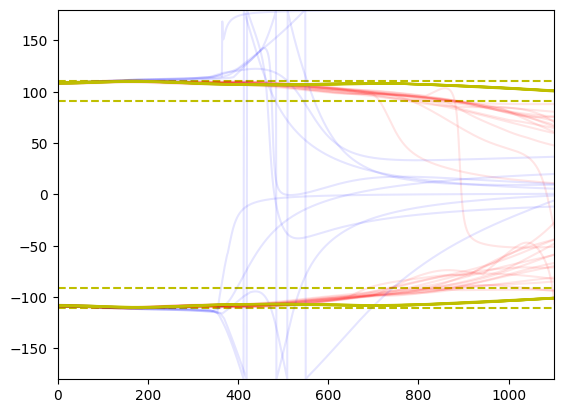

In [134]:
import matplotlib.pyplot as plt
plt.plot(out_dihs, color="y")
plt.axhline(out_dihs[:,0::2].min(), color="y", linestyle="--")
plt.axhline(out_dihs[:,0::2].max(), color="y", linestyle="--")
plt.axhline(out_dihs[:,1::2].min(), color="y", linestyle="--")
plt.axhline(out_dihs[:,1::2].max(), color="y", linestyle="--")
plt.plot(out_dihs0, alpha=0.1, color="r")
plt.plot(out_dihs2, alpha=0.1, color="b")
plt.plot(out_dihs2ell4_100, alpha=0.9, color="y")

plt.xlim(0,1100)
plt.ylim(-180,180)

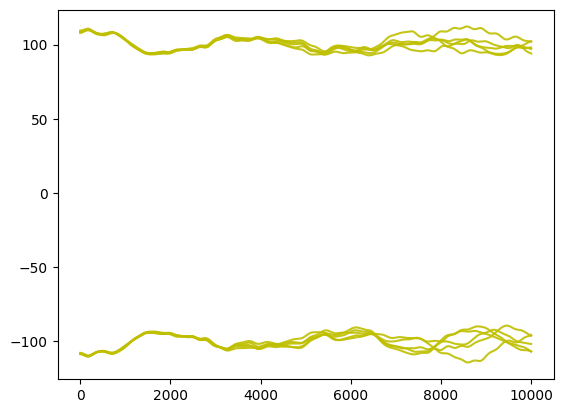

In [132]:
plt.plot(out_dihs2ell4_100, alpha=0.9, color="y")

(array([    0.,   160.,  7667., 16322., 12933.,  8308.,  3744.,   871.,
            0.,     0.]),
 array([ 85. ,  88.5,  92. ,  95.5,  99. , 102.5, 106. , 109.5, 113. ,
        116.5, 120. ]),
 <BarContainer object of 10 artists>)

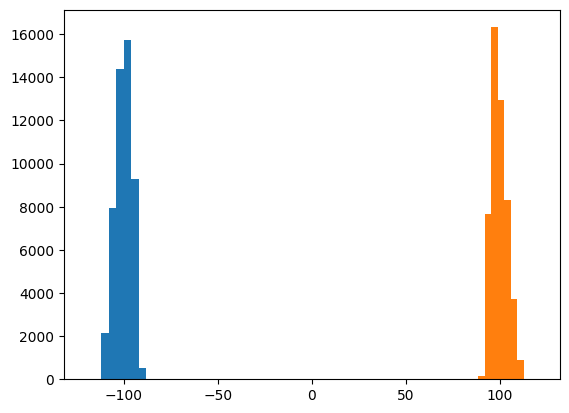

In [95]:
plt.hist(out_dihs.flatten(), range=(-120, -80))
plt.hist(out_dihs.flatten(), range=(85, 120))

In [106]:
out_dihs.min()

Array(-110.707596, dtype=float32)

In [107]:
out_dihs.max()

Array(110.62177, dtype=float32)

In [108]:
data_train = jnp.load("data-full.npz", allow_pickle=True)

In [109]:
data_train

NpzFile 'data-full.npz' with keys: R, Z, D, E, F...

In [135]:
data_train.R

AttributeError: 'NpzFile' object has no attribute 'R'

In [120]:
R = jnp.array(data_train["R"], dtype=jnp.float32)
# R.dtype = 
R.shape, R.dtype

((10000, 1, 29, 3), dtype('float32'))

In [122]:
dihs_ = R[:,:,[0, 2, 9, 11],:]
out_dihs_data_train = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1)

In [125]:
out_dihs_data_train

Array([ 108.622314, -107.96623 ,  108.70798 , ..., -108.443985,
        108.519035, -109.068   ], dtype=float32)

(array([   0.,    0.,    0.,    0.,    0.,    0., 4926.,   74.,    0.,
           0.]),
 array([ 85. ,  88.5,  92. ,  95.5,  99. , 102.5, 106. , 109.5, 113. ,
        116.5, 120. ]),
 <BarContainer object of 10 artists>)

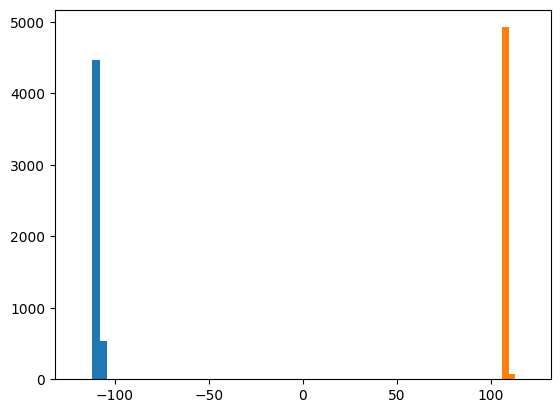

In [126]:
plt.hist(out_dihs_data_train.flatten(), range=(-120, -80))
plt.hist(out_dihs_data_train.flatten(), range=(85, 120))